# Clinical GraphRAG Quick Start

This notebook runs through the Quick Start pipeline (Steps 0–5) from the README.

**Prerequisites:**
- [uv](https://docs.astral.sh/uv/getting-started/installation/) installed
- **API key:** Create `api_keys.json` with your OpenRouter key (see Step 1 below)

**Excluded:** Step 7 (LLM Judge) — optional and costly.

## Setup: Ensure we're in the project root

In [ ]:
import os
from pathlib import Path

# Ensure we're in project root (parent of notebooks/)
cwd = Path.cwd()
if (cwd / "pyproject.toml").exists():
    PROJECT_ROOT = cwd
else:
    PROJECT_ROOT = cwd.parent
    os.chdir(PROJECT_ROOT)

print(f"Project root: {Path.cwd()}")

In [2]:
pass  # Setup complete

## Step 0: Sync dependencies

Run `uv sync` to install project dependencies. (Install uv first: `curl -LsSf https://astral.sh/uv/install.sh | sh`)

In [3]:
!uv sync    # ! Run this cell to install the dependencies (runs in the system shell rather than the notebook kernel)

Resolved 204 packages in 3ms
Audited 116 packages in 2ms


## Step 1: Set your OpenRouter API key

Replace the placeholder below with your key from [OpenRouter](https://openrouter.ai/keys), then run the cell.

In [4]:
import json
from pathlib import Path

OPENROUTER_KEY = "" # ← Replace with your key from https://openrouter.ai/keys
Path("api_keys.json").write_text(json.dumps({"openrouter": OPENROUTER_KEY}, indent=2))

95

## Step 2: KG Extraction

Extract entities and relations from transcripts (single-pass baseline via OpenRouter GLM).

In [5]:
!uv run python -m Clinical_KG_OS_LLM.kg_extraction --output ./my_kg

KG Extraction Pipeline
Method: naive (z-ai/glm-4.7-flash)
Output: my_kg
Processing 2 transcripts
  RES0206... (20n/15e)
  RES0216... (10n/8e)
Done! Success: 2, Failed: 0
Total tokens: 19822
Output: my_kg/


## Step 3: Entity Resolution (Dump Graph)

Merge per-patient KGs into a unified graph. Output: `unified_graph_my_kg.json` when input is `./my_kg`.

In [6]:
!uv run python -m Clinical_KG_OS_LLM.dump_graph --input ./my_kg --output ./my_kg_naive

KG Graph Merger
Input:  my_kg
Output: my_kg_naive/unified_graph_my_kg.json
Loading bge-m3...
Loading weights: 100%|█| 391/391 [00:00<00:00, 13598.22it/s, Materializing param
Loaded 2 sub-KGs: 30 entities, 23 edges
  DIAGNOSIS: 5 unique names
  SYMPTOM: 9 unique names
  MEDICAL_HISTORY: 3 unique names
  TREATMENT: 5 unique names
  PROCEDURE: 3 unique names
  LAB_RESULT: 1 unique names
  LOCATION: 1 unique names

Entity Resolution: 27 -> 27 canonical entities
Saved: my_kg_naive/er_merge_decisions_my_kg.json
Saved: my_kg_naive/unified_graph_my_kg.json

Unified graph: 27 nodes, 23 edges
Done.


## Step 4: GraphRAG QA Pipeline

Answer clinical questions using the unified KG. Use `--questions Q1` for a quick run; omit to run all questions.

In [7]:
!uv run python -m Clinical_KG_OS_LLM.graphrag_qa_pipeline --kg ./my_kg_naive/unified_graph_my_kg.json --questions Q1

=== GraphRAG-QA Pipeline ===
  KG     : my_kg_naive/unified_graph_my_kg.json
  Bundle : /Users/ntebaldi/Documents/workspace/ai+science/projects/hackathon-2026/workspace/Clinical_KG_OS_LLM/data/transcripts
  Output : my_kg_naive/results_unified_graph_my_kg

Loading embedding model (BAAI/bge-m3)...
Loading weights: 100%|█| 391/391 [00:00<00:00, 13964.23it/s, Materializing param

Loading KG (unified_graph_my_kg.json)...
  27 nodes, 23 edges
  Computing embeddings for 27 nodes...
Generating embeddings: 100%|████████████████████| 27/27 [00:00<00:00, 65.34it/s]
  Cached embeddings to embeddings_cache/unified_graph_my_kg.npz

  RES0206  (1 questions)

  [Q1] What specific respiratory and systemic symptoms did this COPD patient report dur...
    retrieval  0.1s
    generation 18.1s (openrouter)
    preview    Based on the transcript and clinical data provided, here is the documentation of the patient's reported symptoms:

**Res...

  Saved → my_kg_naive/results_unified_graph_my_kg/RES0206/RES0

## Step 5: Quick Quality Check

Compare your KG against the curated baseline. Outputs composite score and report.

In [10]:
!uv run python -m Clinical_KG_OS_LLM.kg_similarity_scorer --student ./my_kg_naive/unified_graph_my_kg.json --baseline ./data/baseline_curated/unified_graph_curated.json

KG Similarity Report
Student KG:   ./my_kg_naive/unified_graph_my_kg.json
Baseline KG:  data/baseline_curated/unified_graph_curated.json

  COMPOSITE SCORE: 0.325
  (Correlates r=0.94 with QA performance)

Component Scores:
  Entity F1 (25%):              0.129
  Population Completeness (25%): 0.081
  Relation Completeness (25%):   0.090
  Schema Completeness (25%):     1.000

Detailed Node Overlap:
  Precision: 59.26% (16/27 student nodes matched)
  Recall:    7.24% (16/221 baseline nodes covered)
  F1 Score:  12.90%

Structural Comparison:
  Student:   27 nodes, 23 edges, density 0.85
  Baseline:  222 nodes, 171 edges, density 0.77

Per-Patient Average Coverage: 3.14%

Grade: F (Poor - significant issues)


## Step 6: Visualize the Knowledge Graph

Render your unified KG as a graph (nodes = entities, edges = relations). Use `--res-id` to show one patient's subgraph.

In [11]:
!uv run python -m Clinical_KG_OS_LLM.visualize_kg \
  --kg ./my_kg_naive/unified_graph_my_kg.json \
  --output ./my_kg_naive/kg_graph.png

Saved: my_kg_naive/kg_graph.png


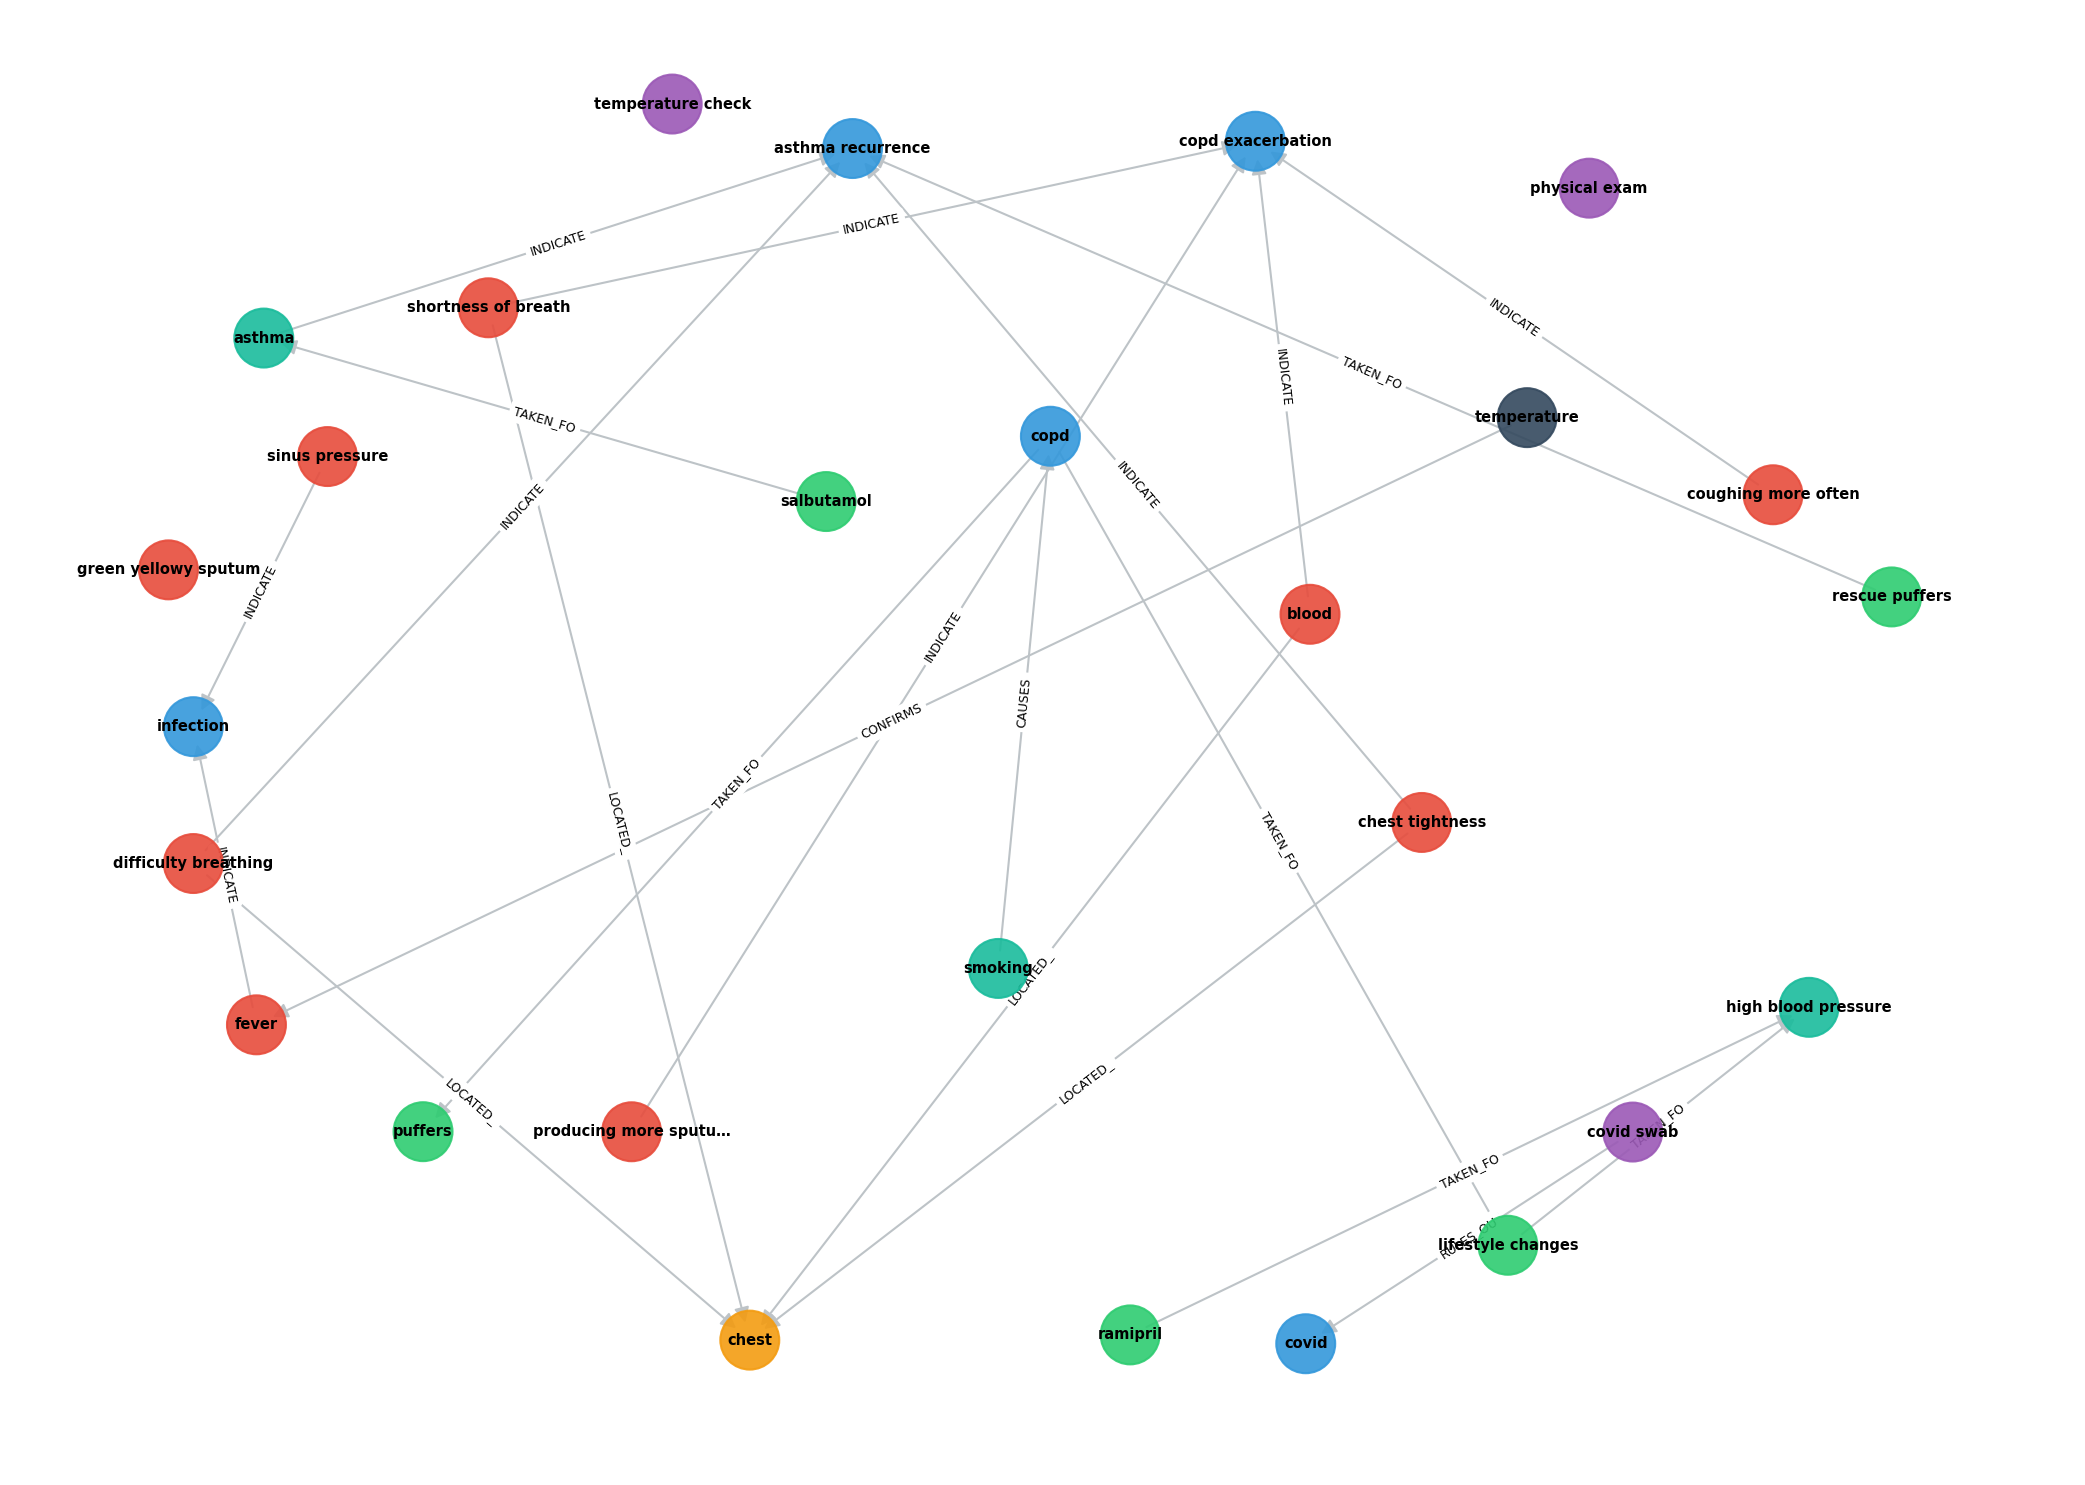

In [12]:
from IPython.display import Image, display
display(Image(filename="./my_kg_naive/kg_graph.png"))

# Check OpenRouter credits [Optional]

In [13]:
os.environ['API_KEY'] = ""  # ← Replace with your key from https://openrouter.ai/keys
!uv run python -m Clinical_KG_OS_LLM.check_openrouter_credits

💳 API Key Credit Balance:
   Key limit:    $1.00
   Key usage:    $0.11
   Remaining:    $0.89


## Done

Pipeline complete. Results:
- **QA answers:** `./my_kg_naive/results_unified_graph_my_kg/`
- **KG graph:** `./my_kg_naive/kg_graph.png`
- **Step 7 (LLM Judge):** Optional, ~$8–10 per run — executed by hackathon organizers only.